In [1]:
### Hayden Gallo
### Bucci Lab
### DySCoMeMo    
### 1/27/26
### Testing how to get MDSINE pickle in sufficient format for utilizing with new scheme for DySCoMeMo 

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import math as m
import seaborn as sns
import pandas as pd
import math
import mdsine2 as md2
from pathlib import Path
import os
from scipy.stats import truncnorm
import json
from Bio import Entrez
from Bio import SeqIO
import time
import pickle
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages
import statsmodels.nonparametric.smoothers_lowess as loess

from scipy.signal import savgol_filter

from tqdm import tqdm
from matplotlib.lines import Line2D
#from whittaker_eilers import WhittakerSmoother

[DEBUG] Using default logger (stdout, stderr).


In [2]:
### gLV function with perturbations

def gLV_perturb(t, init_abun, int_matrix, basal_grow, perturbations):

    """gLV model with perturbations incorporated as step functions.
    
    Args:
        t (float): time
        init_abun (array): array of initial abundances for each species
        int_matrix (2D array): interaction matrix between species
        basal_grow (array): array of basal growth rates for each species
        perturbations (array): array of perturbation magnitudes for each species
        
    
    Returns:
        dXdt (array): rate of change of abundances
    """
    # Determine current perturbation state based on time

    if t <= 1.0 or t >= 3.0:
        current_perturb = np.zeros(len(init_abun))
    else:
        current_perturb = perturbations
        print('perturbation')
    
    # Calculate the rate of change of abundances
    dXdt = init_abun * (basal_grow + np.dot(int_matrix, init_abun) + current_perturb)
    
    return dXdt

In [151]:
# Load pkls from the MDSINE2 inference

data_dir = Path('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl')

os.chdir(data_dir)
print(os.getcwd())

/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl


In [152]:
### load in the growth rates
growth_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl/posterior/growth/values.tsv', sep = '\t')
### load in interaction matrix
int_matrix_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl/posterior/interactions/mean_matrix.tsv', sep = '\t', index_col=0)
### load in self interactions
self_ints_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl/posterior/self_interactions/values.tsv', sep = '\t')
### load in perturbations 
perturbations_df = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl/posterior/ABX/values.tsv', sep = '\t')

In [153]:
growth_rates_mean = growth_df.loc[1:,'mean']
growth_rates_mean

1     12534.704616
2     10518.504691
3     10056.336737
4     14395.376838
5      8315.078009
6     11584.339227
7     16128.281278
8     10459.111058
9     10098.789834
10     9648.851114
11    15855.696743
12     9473.447416
13     9029.667731
14    11204.353233
15    14562.259755
Name: mean, dtype: float64

In [154]:
int_matrix_df

,14ac4eaad5b4e2ff3c071832e0fd4229,18673193aa6bf30c6a1e71ac504e04df,320dfd16200daaf2b0503975d4e68fd5,36173253c63ad49abc12361a0b3304eb,391821255f31ef94686927f4fba6fbc3,3936cc515320e9f29d81ffeaa92718e8,3e741fc097143bb6782af5233cb7af98,4cc9a4b9aaa3ee9a5c14cc27551a6844,795b6ba45f502a00b24b212278991c63,7ca7ca8214441730c2437d1f53390cdb,94e30534f622e456a683abe4e60fc214,9cf5cb71450a2aa080ff905f89b0a624,e3147edad1f84fae8bb6fd6f5e7a97b9,e8aae590cf49eb3c80ad7e08f2d3c3c4,eba523a4a554db4ad7e9dcff257bf1c8
14ac4eaad5b4e2ff3c071832e0fd4229,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18673193aa6bf30c6a1e71ac504e04df,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
320dfd16200daaf2b0503975d4e68fd5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36173253c63ad49abc12361a0b3304eb,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
391821255f31ef94686927f4fba6fbc3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3936cc515320e9f29d81ffeaa92718e8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3e741fc097143bb6782af5233cb7af98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4cc9a4b9aaa3ee9a5c14cc27551a6844,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
795b6ba45f502a00b24b212278991c63,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7ca7ca8214441730c2437d1f53390cdb,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [155]:
self_ints_df

,Unnamed: 0,name,median,mean,25th percentile,75th percentile
0,mean,Mean parameter for the truncated normal prior ...,1.707458e+01,1.678862e+01,1.532670e+01,1.820323e+01
1,14ac4eaad5b4e2ff3c071832e0fd4229,Bifidobacterium 14ac4eaad5b4e2ff3c071832e0fd42...,1.207856e-08,1.264223e-07,4.285455e-09,1.437921e-07
2,18673193aa6bf30c6a1e71ac504e04df,Jeotgalicoccus 18673193aa6bf30c6a1e71ac504e04d...,1.177602e-06,3.041741e-06,1.437815e-07,3.242357e-06
3,320dfd16200daaf2b0503975d4e68fd5,Lactobacillus Lactobacillus reuteri 320dfd1620...,1.160059e-08,3.353870e-08,7.916499e-10,4.692336e-08
4,36173253c63ad49abc12361a0b3304eb,uncultured uncultured bacterium 36173253c63ad4...,1.331799e-07,4.272379e-07,3.911272e-08,5.372205e-07
5,391821255f31ef94686927f4fba6fbc3,uncultured bacterium uncultured bacterium 3918...,6.091922e-08,1.737304e-07,1.095840e-08,1.637392e-07
6,3936cc515320e9f29d81ffeaa92718e8,[Eubacterium] coprostanoligenes group 3936cc51...,3.553052e-08,1.173434e-07,5.408476e-09,8.939327e-08
7,3e741fc097143bb6782af5233cb7af98,uncultured bacterium uncultured bacterium 3e74...,4.992735e-07,1.319060e-06,5.625855e-08,1.133397e-06
8,4cc9a4b9aaa3ee9a5c14cc27551a6844,Enterococcus 4cc9a4b9aaa3ee9a5c14cc27551a6844 ...,3.749351e-08,1.112915e-07,4.483464e-09,1.485482e-07
9,795b6ba45f502a00b24b212278991c63,Turicibacter uncultured bacterium 795b6ba45f50...,2.085082e-08,6.494538e-08,4.294637e-09,1.326020e-07


In [156]:
self_ints = self_ints_df.loc[1:,'mean']
self_ints = -np.absolute(self_ints)

In [157]:
for i in range(0, self_ints.shape[0]):
    int_matrix_df.iloc[i,i] = self_ints.iloc[i]


int_matrix_df

,14ac4eaad5b4e2ff3c071832e0fd4229,18673193aa6bf30c6a1e71ac504e04df,320dfd16200daaf2b0503975d4e68fd5,36173253c63ad49abc12361a0b3304eb,391821255f31ef94686927f4fba6fbc3,3936cc515320e9f29d81ffeaa92718e8,3e741fc097143bb6782af5233cb7af98,4cc9a4b9aaa3ee9a5c14cc27551a6844,795b6ba45f502a00b24b212278991c63,7ca7ca8214441730c2437d1f53390cdb,94e30534f622e456a683abe4e60fc214,9cf5cb71450a2aa080ff905f89b0a624,e3147edad1f84fae8bb6fd6f5e7a97b9,e8aae590cf49eb3c80ad7e08f2d3c3c4,eba523a4a554db4ad7e9dcff257bf1c8
14ac4eaad5b4e2ff3c071832e0fd4229,-1.264223e-07,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
18673193aa6bf30c6a1e71ac504e04df,0.000000e+00,-0.000003,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
320dfd16200daaf2b0503975d4e68fd5,0.000000e+00,0.000000,-3.353870e-08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
36173253c63ad49abc12361a0b3304eb,0.000000e+00,0.000000,0.000000e+00,-4.272379e-07,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
391821255f31ef94686927f4fba6fbc3,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,-1.737304e-07,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
3936cc515320e9f29d81ffeaa92718e8,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,-1.173434e-07,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
3e741fc097143bb6782af5233cb7af98,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-0.000001,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
4cc9a4b9aaa3ee9a5c14cc27551a6844,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1.112915e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
795b6ba45f502a00b24b212278991c63,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,-6.494538e-08,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
7ca7ca8214441730c2437d1f53390cdb,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,-8.190335e-08,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000


In [158]:
perturbations_mean = -np.absolute(perturbations_df.loc[:,'mean'])
perturbations_mean

0    -0.000000
1    -0.000000
2    -0.000000
3    -0.000000
4    -0.108431
5    -0.000000
6    -0.000000
7    -0.000000
8    -0.000000
9    -0.000000
10   -0.000000
11   -0.000000
12   -0.000000
13   -0.000000
14   -0.000000
Name: mean, dtype: float64

In [3]:
### load in refseq to agora with name mappings 
refseq_to_agora = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/refseq_to_agora_update_07_07_25.csv')

#refseq_to_agora = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/refseq_to_agora_update_07_07_25.csv')
refseq_to_agora

asv_to_agora_dict = dict(zip(refseq_to_agora['ASV_string'], refseq_to_agora['Agora_Name']))
asv_to_agora_dict

{'14ac4eaad5b4e2ff3c071832e0fd4229': 'Bifidobacterium_pseudolongum',
 '18673193aa6bf30c6a1e71ac504e04df': 'Jeotgalicoccus_nanhaiensis',
 '320dfd16200daaf2b0503975d4e68fd5': 'Lactobacillus_reuteri',
 '36173253c63ad49abc12361a0b3304eb': 'Merdibacter_massiliensis',
 '391821255f31ef94686927f4fba6fbc3': 'Duncaniealla_sp',
 '3936cc515320e9f29d81ffeaa92718e8': 'Ruminococcus_bicirculans',
 '3e741fc097143bb6782af5233cb7af98': 'Muribaculum_intestinale',
 '4cc9a4b9aaa3ee9a5c14cc27551a6844': 'Enterococcus_faecalis',
 '795b6ba45f502a00b24b212278991c63': 'Turicibacter_sp',
 '7ca7ca8214441730c2437d1f53390cdb': 'Erysipelotrichaceae_sp',
 '94e30534f622e456a683abe4e60fc214': 'Lactobacillus_murinus',
 '9cf5cb71450a2aa080ff905f89b0a624': 'Bacteroides_caecimuris',
 'e3147edad1f84fae8bb6fd6f5e7a97b9': 'Lactobacillus_intestinalis',
 'e8aae590cf49eb3c80ad7e08f2d3c3c4': 'Lactobacillus_gasseri',
 'eba523a4a554db4ad7e9dcff257bf1c8': 'Staphylococcus_LKG31'}

In [4]:
### Subject to simulate 
subject_to_plot = 1953

In [5]:
output_folder = 'filtering_hourly_resolution'

output_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/' + output_folder + '/Subject_' + str(subject_to_plot) + '/mean_smoothed.tsv'

#output_path = '/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/' + output_folder + '/Subject_' + str(subject_to_plot) + '/mean_smoothed.tsv'
MDSINE_output = pd.read_csv(output_path, delimiter='\t', index_col=0)

MDSINE_output_raw = MDSINE_output.copy()

In [6]:
MDSINE_output = MDSINE_output.melt(ignore_index=False)
MDSINE_output = MDSINE_output.reset_index()
MDSINE_output.columns = ['species','time', 'count']
MDSINE_output['time'] = MDSINE_output['time'].astype(float)

MDSINE_output

,species,time,count
0,14ac4eaad5b4e2ff3c071832e0fd4229,-3.0,6.669566e+08
1,18673193aa6bf30c6a1e71ac504e04df,-3.0,6.163075e+03
2,320dfd16200daaf2b0503975d4e68fd5,-3.0,2.732440e+08
3,36173253c63ad49abc12361a0b3304eb,-3.0,8.762357e+07
4,391821255f31ef94686927f4fba6fbc3,-3.0,5.160079e+07
...,...,...,...
6235,94e30534f622e456a683abe4e60fc214,14.0,6.020772e+09
6236,9cf5cb71450a2aa080ff905f89b0a624,14.0,1.256542e+03
6237,e3147edad1f84fae8bb6fd6f5e7a97b9,14.0,8.709853e+01
6238,e8aae590cf49eb3c80ad7e08f2d3c3c4,14.0,3.571719e+09


In [7]:
times = np.linspace(0,17,4160)

perturb_times_df = pd.DataFrame({'time': times})
perturb_times_df['perturb'] = ((perturb_times_df['time'] >= 2.0) & (perturb_times_df['time'] <= 5.0)).astype(int)
perturb_times_df

,time,perturb
0,0.000000,0
1,0.004088,0
2,0.008175,0
3,0.012263,0
4,0.016350,0
...,...,...
4155,16.983650,0
4156,16.987737,0
4157,16.991825,0
4158,16.995912,0


In [8]:
#### make everything into arrays 

int_array = np.array(int_matrix_df)
basal_grow_array = np.array(growth_rates_mean)
perturb_array = np.array(perturbations_mean)

NameError: name 'int_matrix_df' is not defined

In [165]:
args = (int_array, basal_grow_array, perturb_array)

In [9]:
### reload everything in 
growth_array = np.array(pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/median_grow.csv', index_col=0)).reshape(-1)

#growth_array = np.array(pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/median_grow.csv', index_col=0)).reshape(-1)
growth_array

array([0.85315574, 0.28639573, 0.67762913, 0.10760468, 0.41161314,
       0.8168768 , 0.13197057, 0.20803693, 0.46017088, 0.1307683 ,
       0.29185633, 0.05725774, 0.18101538, 0.12213617, 0.29930456])

In [10]:
int_array = np.array(pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/median_interactions.csv', index_col=0))
#int_array = np.array(pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/median_interactions.csv', index_col=0))
int_array

array([[-8.47700426e-11, -2.16062410e-10,  0.00000000e+00,
        -1.04854015e-10,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -5.87852273e-12,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -5.37454043e-10,  0.00000000e+00,
        -4.18480078e-10,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -1.96985775e-11,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -1.55015365e-10, -7.15871688e-11,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -1.93249275e-10,  0.00000000e+00,
        -2.51827532e-10,  0.00000000e+00,  0.00000000

In [11]:
perturb_array = np.array(pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/median_perturbations_test.csv', index_col=0)).reshape(-1)
#perturb_array = np.array(pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/median_perturbations_test.csv', index_col=0)).reshape(-1)

perturb_array

array([  0.        ,  19.05517009,   0.        , -17.600262  ,
        -3.42336203,  -5.32271871, -17.88544903,   0.        ,
         0.        ,   0.43819503,   2.8660313 ,   1.78279778,
         2.98758308,  13.00483493,  12.75820391])

In [300]:
init_abun = init_abun.reshape(1,-1)

In [12]:
init_abun

NameError: name 'init_abun' is not defined

In [288]:
a-rgs = (int_array, growth_array, perturb_array)

In [301]:
sol_odeint = odeint(gLV_perturb, init_abun,times, args = args, tfirst = True)

ValueError: Initial condition y0 must be one-dimensional.

In [171]:
sol_odeint_df = pd.DataFrame(sol_odeint, columns = MDSINE_output_raw.index, index = times)
sol_odeint_df = sol_odeint_df.melt(ignore_index=False).reset_index()
sol_odeint_df.columns = ['time','species', 'count']
sol_odeint_df['time'] = sol_odeint_df['time'] - 3.0

In [302]:
dt = 0.01
t = np.arange(0, 17, dt)

u = np.zeros((len(t), 1))
u[(t >= 1.0) & (t < 3.0), 0] = 1.0
u


array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]])

In [303]:
def gLV_perturb(x, t, paired_growth_matrix, basal_grow,
                gamma, u, dt):
    """
    gLV model with MDSINE2-style perturbations (odeint-compatible).
    """

    # map continuous time -> discrete perturbation index
    k = int(t / dt)
    if k >= u.shape[0]:
        k = u.shape[0] - 1

    # perturbation term
    current_perturb = gamma @ u[k]

    # gLV RHS
    dXdt = x * (
        basal_grow
        + paired_growth_matrix @ x
        + current_perturb
    )

    return dXdt


In [304]:
print(int_array.shape)
print(growth_array.shape)
print(perturb_array.shape)
print(u.shape)
print(init_abun.shape)

(15, 15)
(15,)
(15, 1)
(1700, 1)
(1, 15)


In [305]:
perturb_array = perturb_array.reshape(-1, 1)
perturb_array.shape

(15, 1)

In [306]:
t = np.arange(0, 17, dt)

x = odeint(
    gLV_perturb,
    init_abun,
    t,
    args=(int_array, growth_array, perturb_array, u, dt)
)


ValueError: Initial condition y0 must be one-dimensional.

In [193]:
sol_odeint_df = pd.DataFrame(x, columns = MDSINE_output_raw.index)
sol_odeint_df = sol_odeint_df.melt(ignore_index=False).reset_index()
sol_odeint_df.columns = ['time','species', 'count']
sol_odeint_df['time'] = (sol_odeint_df['time']/100)-3.0

14ac4eaad5b4e2ff3c071832e0fd4229


NameError: name 'sol_odeint_df' is not defined

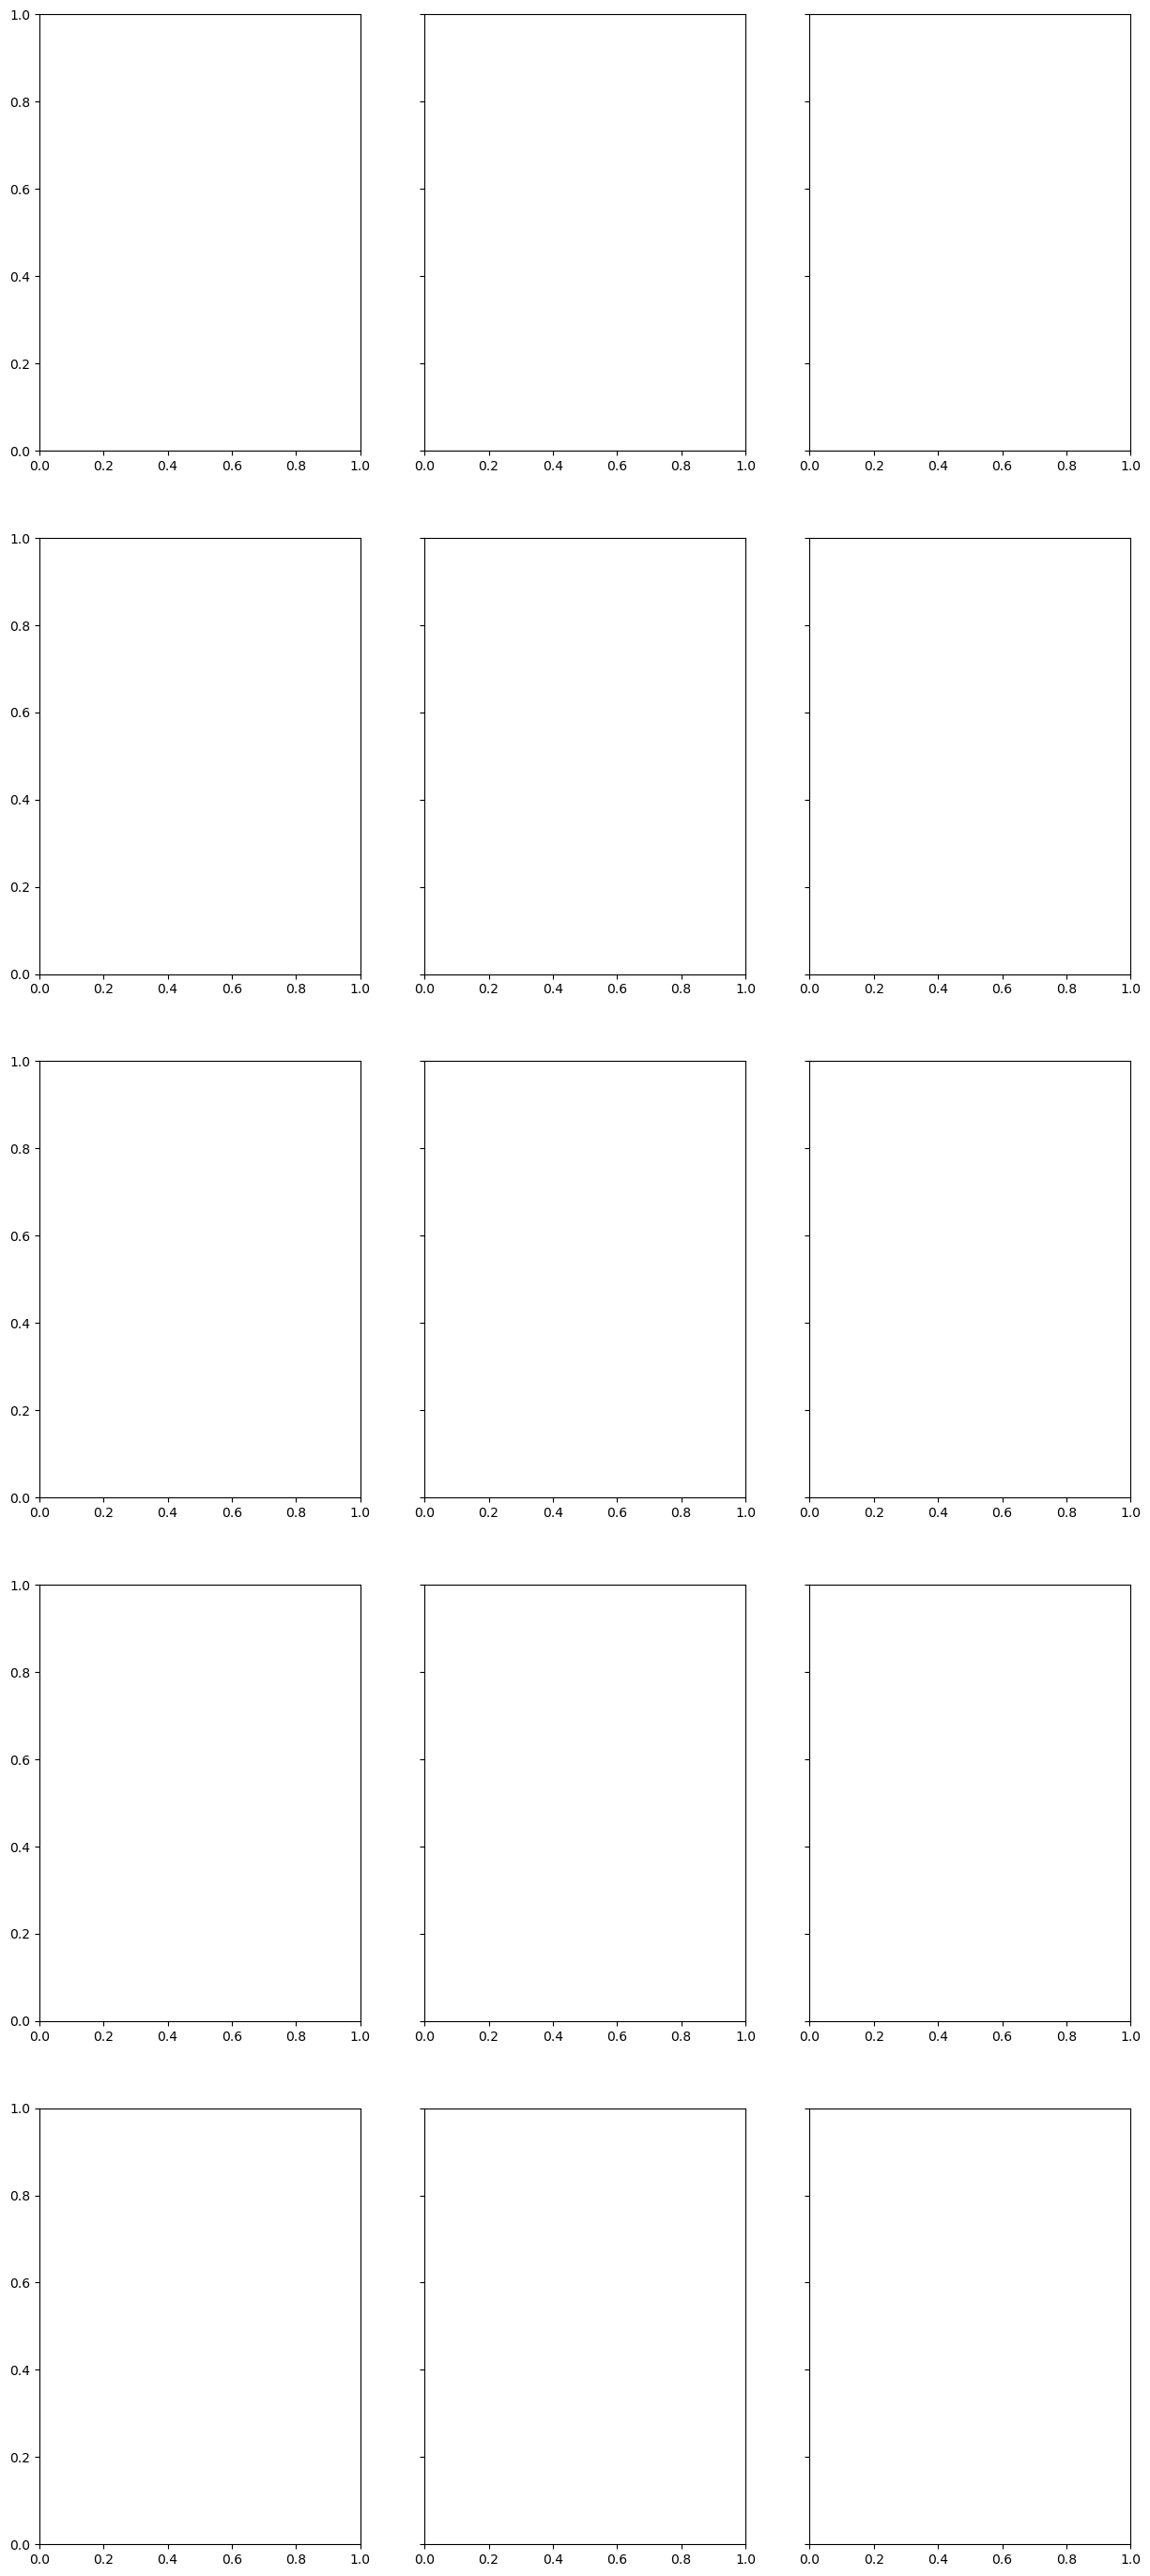

In [254]:
num_plots = 15
cols = 3  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 7), constrained_layout=False, sharey = True)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, species in enumerate(asv_to_agora_dict.keys()):
    print(species)
    temp_sim = sol_odeint_df[sol_odeint_df['species'] == species]
    #temp_exp = testing_melt_abs_abun_plotting[testing_melt_abs_abun_plotting['species'] == species]
    temp_mdsine = MDSINE_output[MDSINE_output['species'] == species]
        # Scatter plot on the respective subplot
    
    #sns.lineplot(ax = axes[i], x = temp_exp['time'], y = temp_exp['count'], c = 'blue', lw = 2)
    sns.lineplot(ax=axes[i], x=temp_sim['time'], y=temp_sim['count'], c = 'red', lw =2)
    sns.lineplot(ax=axes[i], x=temp_mdsine['time'], y=temp_mdsine['count'], c = 'black', lw =2)
    
    species = asv_to_agora_dict[species]
    axes[i].set_title(f"{species}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Couunt')
    axes[i].set_yscale('log')
    
    

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Create color legend (data sources)
color_legend_elements = [
    Line2D([0], [0], color='blue', lw=3, label='Exp'),
    Line2D([0], [0], color='red', lw=3, label='Sim'),
    Line2D([0], [0], color='black', lw=3, label='MDSINE')
]


# Add both legends below the plots
color_legend = fig.legend(handles=color_legend_elements, loc='upper center', 
                          bbox_to_anchor=(.5, .925), ncol=3, fontsize=20, title="Method")
#axs.legend(['Mean EB Abun', 'EB 95% CI', 'Mean PC Abun', 'PC 95% CI', 'EB Data', 'PC Data'])
#plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_individual_scatterplots_smoothed_predictions' + str(test_num) + '.pdf'
#plt.savefig(plot_file_name, bbox_inches="tight")

In [255]:
### load in the pickle 


#data_dir = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun//MDSINE_vs_Exp_plots_filtering_hourly_resolution/merged_studies_fixed_cluster_hourly_resolution_mcmc_pkl')


data_dir = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/merged_studies_fixed_cluster_100_its_daily')


pkl_path = data_dir / "mcmc.pkl"


mcmc = md2.BaseMCMC.load(str(pkl_path))

In [256]:
growth = mcmc.graph[STRNAMES.GROWTH_VALUE].get_trace_from_disk()
self_interactions = mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE].get_trace_from_disk()
interactions = mcmc.graph[STRNAMES.INTERACTIONS_OBJ].get_trace_from_disk()
interactions[np.isnan(interactions)] = 0
self_interactions = -np.absolute(self_interactions)
for i in range(self_interactions.shape[1]):
    interactions[:, i, i] = self_interactions[:, i]

In [257]:
if mcmc.graph.perturbations is not None:
            perturbations = []
            perturbations_start = []
            perturbations_end = []
            for pert in mcmc.graph.perturbations:
                print('perturbations found')
                pert_value = pert.get_trace_from_disk()
                pert_value[np.isnan(pert_value)] = 0.

                perturbations.append(pert_value)
                perturbations_start.append(pert.starts['1953'])
                perturbations_end.append(pert.ends['1953'])
else:
    logger.info('No perturbations found.')
    perturbations = None
    perturbations_start = []
    perturbations_end = []

perturbations found


In [258]:
growth_mean = np.mean(growth, axis=0)
interactions_mean = np.mean(interactions,axis=0)
perturbations_mean = np.mean(perturbations, axis=1)

In [259]:
perturbations_mean.shape

(1, 15)

In [283]:
perturbations_start

[-2]

In [260]:
dyn = md2.model.gLVDynamicsSingleClustering(growth=growth_mean, interactions=interactions_mean, perturbations=perturbations_mean, perturbation_starts = perturbations_start, perturbation_ends = perturbations_end, start_day = -3)

In [277]:
x = md2.integrate(dynamics=dyn, initial_conditions=init_abun, dt=.001, n_days=17)

[DEBUG] Simulating 10000/17001


In [278]:
abun_test = x['X']
abun_test = np.nan_to_num(abun_test, nan=0)

abun_test_df = pd.DataFrame(abun_test)


In [76]:
md2.cli.helpers.fwsim_helper.run_forward_sim(growth=growth, interactions=interactions, initial_conditions=init_abun, perturbations=perturbations, perturbation_starts = perturbations_start, perturbation_ends = perturbations_end, dt = .1, start_time = -3, final_day = 14)

AttributeError: module 'mdsine2' has no attribute 'cli'

In [87]:
#### load in the subject 




subj_pkl_path = data_dir / "subjset.pkl"


subjset = md2.BaseMCMC.load(str(subj_pkl_path))
subjset

AttributeError: 'Study' object has no attribute 'tracer'

In [91]:
subject = mcmc.graph.data.subjects['1953']

In [120]:
subject.perturbations['ABX'].starts[subject.name] = 1

subject.perturbations['ABX'].starts[subject.name]

1

In [121]:
subject.perturbations['ABX'].ends[subject.name] = 3

subject.perturbations['ABX'].ends[subject.name]

3

In [199]:
x=md2.model.gLVDynamicsSingleClustering.forward_sim_from_chain(mcmc=mcmc, initial_conditions = init_abun, subj = subject, times = np.linspace(0,17,18), simulation_dt = .01)

[INFO] 5/25 - 0.04207301139831543


[INFO] 10/25 - 0.044119834899902344
[INFO] 15/25 - 0.04571795463562012
[INFO] 20/25 - 0.042832136154174805


In [200]:
x_filled = np.nan_to_num(x, nan=0)
x_filled

array([[[6.66956615e+08, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [6.16307508e+03, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.73243951e+08, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [3.14999404e+08, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [3.15548232e+08, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.66539349e+04, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[6.66956615e+08, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [6.16307508e+03, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.73243951e+08, 

In [247]:
x_filled_mean = np.mean(x_filled,axis=0)
x_filled_mean_df = pd.DataFrame(x_filled_mean)
x_filled_mean_df.index = MDSINE_output_raw.index
x_filled_mean_df

abun_test_df.index = MDSINE_output_raw.index

In [202]:
x_filled_mean_df_melt = x_filled_mean_df.melt(ignore_index=False).reset_index()
x_filled_mean_df_melt.columns = ['species','time', 'count']
x_filled_mean_df_melt['time'] = x_filled_mean_df_melt['time'] - 3
x_filled_mean_df_melt

,species,time,count
0,14ac4eaad5b4e2ff3c071832e0fd4229,-3,6.669566e+08
1,18673193aa6bf30c6a1e71ac504e04df,-3,6.163075e+03
2,320dfd16200daaf2b0503975d4e68fd5,-3,2.732440e+08
3,36173253c63ad49abc12361a0b3304eb,-3,8.762357e+07
4,391821255f31ef94686927f4fba6fbc3,-3,5.160079e+07
...,...,...,...
265,94e30534f622e456a683abe4e60fc214,14,2.870154e+07
266,9cf5cb71450a2aa080ff905f89b0a624,14,4.704182e+04
267,e3147edad1f84fae8bb6fd6f5e7a97b9,14,1.582554e+07
268,e8aae590cf49eb3c80ad7e08f2d3c3c4,14,1.214852e+09


In [279]:
abun_test_df.index = MDSINE_output_raw.index
abun_test_df

,0,1,2,3,4,5,6,7,8,9,...,16991,16992,16993,16994,16995,16996,16997,16998,16999,17000
14ac4eaad5b4e2ff3c071832e0fd4229,6.669566e+08,6.682852e+08,6.696164e+08,6.709500e+08,6.722863e+08,6.727373e+08,6.731886e+08,6.736401e+08,6.740919e+08,6.745440e+08,...,6.465786e+09,6.465801e+09,6.465816e+09,6.465831e+09,6.465846e+09,6.465861e+09,6.465876e+09,6.465891e+09,6.465905e+09,6.465920e+09
18673193aa6bf30c6a1e71ac504e04df,6.163075e+03,6.198506e+03,6.234141e+03,6.269981e+03,6.306026e+03,6.307129e+03,6.308232e+03,6.309335e+03,6.310439e+03,6.311542e+03,...,1.475543e+03,1.475243e+03,1.474943e+03,1.474643e+03,1.474342e+03,1.474042e+03,1.473742e+03,1.473442e+03,1.473143e+03,1.472843e+03
320dfd16200daaf2b0503975d4e68fd5,2.732440e+08,2.736428e+08,2.740422e+08,2.744422e+08,2.748427e+08,2.750175e+08,2.751924e+08,2.753674e+08,2.755425e+08,2.757177e+08,...,9.375005e+09,9.375008e+09,9.375010e+09,9.375013e+09,9.375016e+09,9.375018e+09,9.375021e+09,9.375024e+09,9.375027e+09,9.375029e+09
36173253c63ad49abc12361a0b3304eb,8.762357e+07,8.744275e+07,8.726230e+07,8.708223e+07,8.690254e+07,8.691061e+07,8.691869e+07,8.692677e+07,8.693485e+07,8.694292e+07,...,6.947073e+07,6.946706e+07,6.946338e+07,6.945971e+07,6.945604e+07,6.945237e+07,6.944870e+07,6.944503e+07,6.944136e+07,6.943769e+07
391821255f31ef94686927f4fba6fbc3,5.160079e+07,5.147667e+07,5.135283e+07,5.122929e+07,5.110604e+07,5.112699e+07,5.114795e+07,5.116892e+07,5.118989e+07,5.121088e+07,...,4.163280e+09,4.163369e+09,4.163458e+09,4.163547e+09,4.163636e+09,4.163725e+09,4.163814e+09,4.163903e+09,4.163992e+09,4.164081e+09
3936cc515320e9f29d81ffeaa92718e8,1.114434e+03,1.110162e+03,1.105905e+03,1.101665e+03,1.097441e+03,1.098201e+03,1.098961e+03,1.099721e+03,1.100483e+03,1.101245e+03,...,9.161125e+06,9.165125e+06,9.169127e+06,9.173131e+06,9.177136e+06,9.181143e+06,9.185152e+06,9.189162e+06,9.193174e+06,9.197188e+06
3e741fc097143bb6782af5233cb7af98,7.706825e+06,7.686011e+06,7.665253e+06,7.644551e+06,7.623905e+06,7.624644e+06,7.625384e+06,7.626123e+06,7.626863e+06,7.627602e+06,...,2.570760e+06,2.570423e+06,2.570086e+06,2.569749e+06,2.569412e+06,2.569075e+06,2.568739e+06,2.568402e+06,2.568066e+06,2.567729e+06
4cc9a4b9aaa3ee9a5c14cc27551a6844,2.774208e+02,2.776309e+02,2.778411e+02,2.780515e+02,2.782621e+02,2.783458e+02,2.784295e+02,2.785133e+02,2.785970e+02,2.786808e+02,...,1.545097e+03,1.545083e+03,1.545068e+03,1.545054e+03,1.545039e+03,1.545025e+03,1.545010e+03,1.544996e+03,1.544981e+03,1.544967e+03
795b6ba45f502a00b24b212278991c63,6.866884e+08,6.870901e+08,6.874919e+08,6.878940e+08,6.882963e+08,6.886085e+08,6.889209e+08,6.892334e+08,6.895460e+08,6.898588e+08,...,1.617232e+10,1.617242e+10,1.617252e+10,1.617262e+10,1.617272e+10,1.617283e+10,1.617293e+10,1.617303e+10,1.617313e+10,1.617323e+10
7ca7ca8214441730c2437d1f53390cdb,5.831325e+09,5.829069e+09,5.826815e+09,5.824564e+09,5.822315e+09,5.818924e+09,5.815537e+09,5.812154e+09,5.808775e+09,5.805401e+09,...,2.406597e+08,2.406237e+08,2.405877e+08,2.405518e+08,2.405158e+08,2.404799e+08,2.404439e+08,2.404080e+08,2.403721e+08,2.403362e+08


In [280]:
abun_test_df_melt = abun_test_df.melt(ignore_index=False).reset_index()
abun_test_df_melt.columns = ['species','time', 'count']
abun_test_df_melt['time'] = (abun_test_df_melt['time']/1000)-3
abun_test_df_melt

,species,time,count
0,14ac4eaad5b4e2ff3c071832e0fd4229,-3.0,6.669566e+08
1,18673193aa6bf30c6a1e71ac504e04df,-3.0,6.163075e+03
2,320dfd16200daaf2b0503975d4e68fd5,-3.0,2.732440e+08
3,36173253c63ad49abc12361a0b3304eb,-3.0,8.762357e+07
4,391821255f31ef94686927f4fba6fbc3,-3.0,5.160079e+07
...,...,...,...
255010,94e30534f622e456a683abe4e60fc214,14.0,2.793855e+09
255011,9cf5cb71450a2aa080ff905f89b0a624,14.0,5.981413e+05
255012,e3147edad1f84fae8bb6fd6f5e7a97b9,14.0,1.839045e+08
255013,e8aae590cf49eb3c80ad7e08f2d3c3c4,14.0,5.828150e+07


14ac4eaad5b4e2ff3c071832e0fd4229
18673193aa6bf30c6a1e71ac504e04df
320dfd16200daaf2b0503975d4e68fd5
36173253c63ad49abc12361a0b3304eb
391821255f31ef94686927f4fba6fbc3
3936cc515320e9f29d81ffeaa92718e8
3e741fc097143bb6782af5233cb7af98
4cc9a4b9aaa3ee9a5c14cc27551a6844
795b6ba45f502a00b24b212278991c63
7ca7ca8214441730c2437d1f53390cdb
94e30534f622e456a683abe4e60fc214
9cf5cb71450a2aa080ff905f89b0a624
e3147edad1f84fae8bb6fd6f5e7a97b9
e8aae590cf49eb3c80ad7e08f2d3c3c4
eba523a4a554db4ad7e9dcff257bf1c8


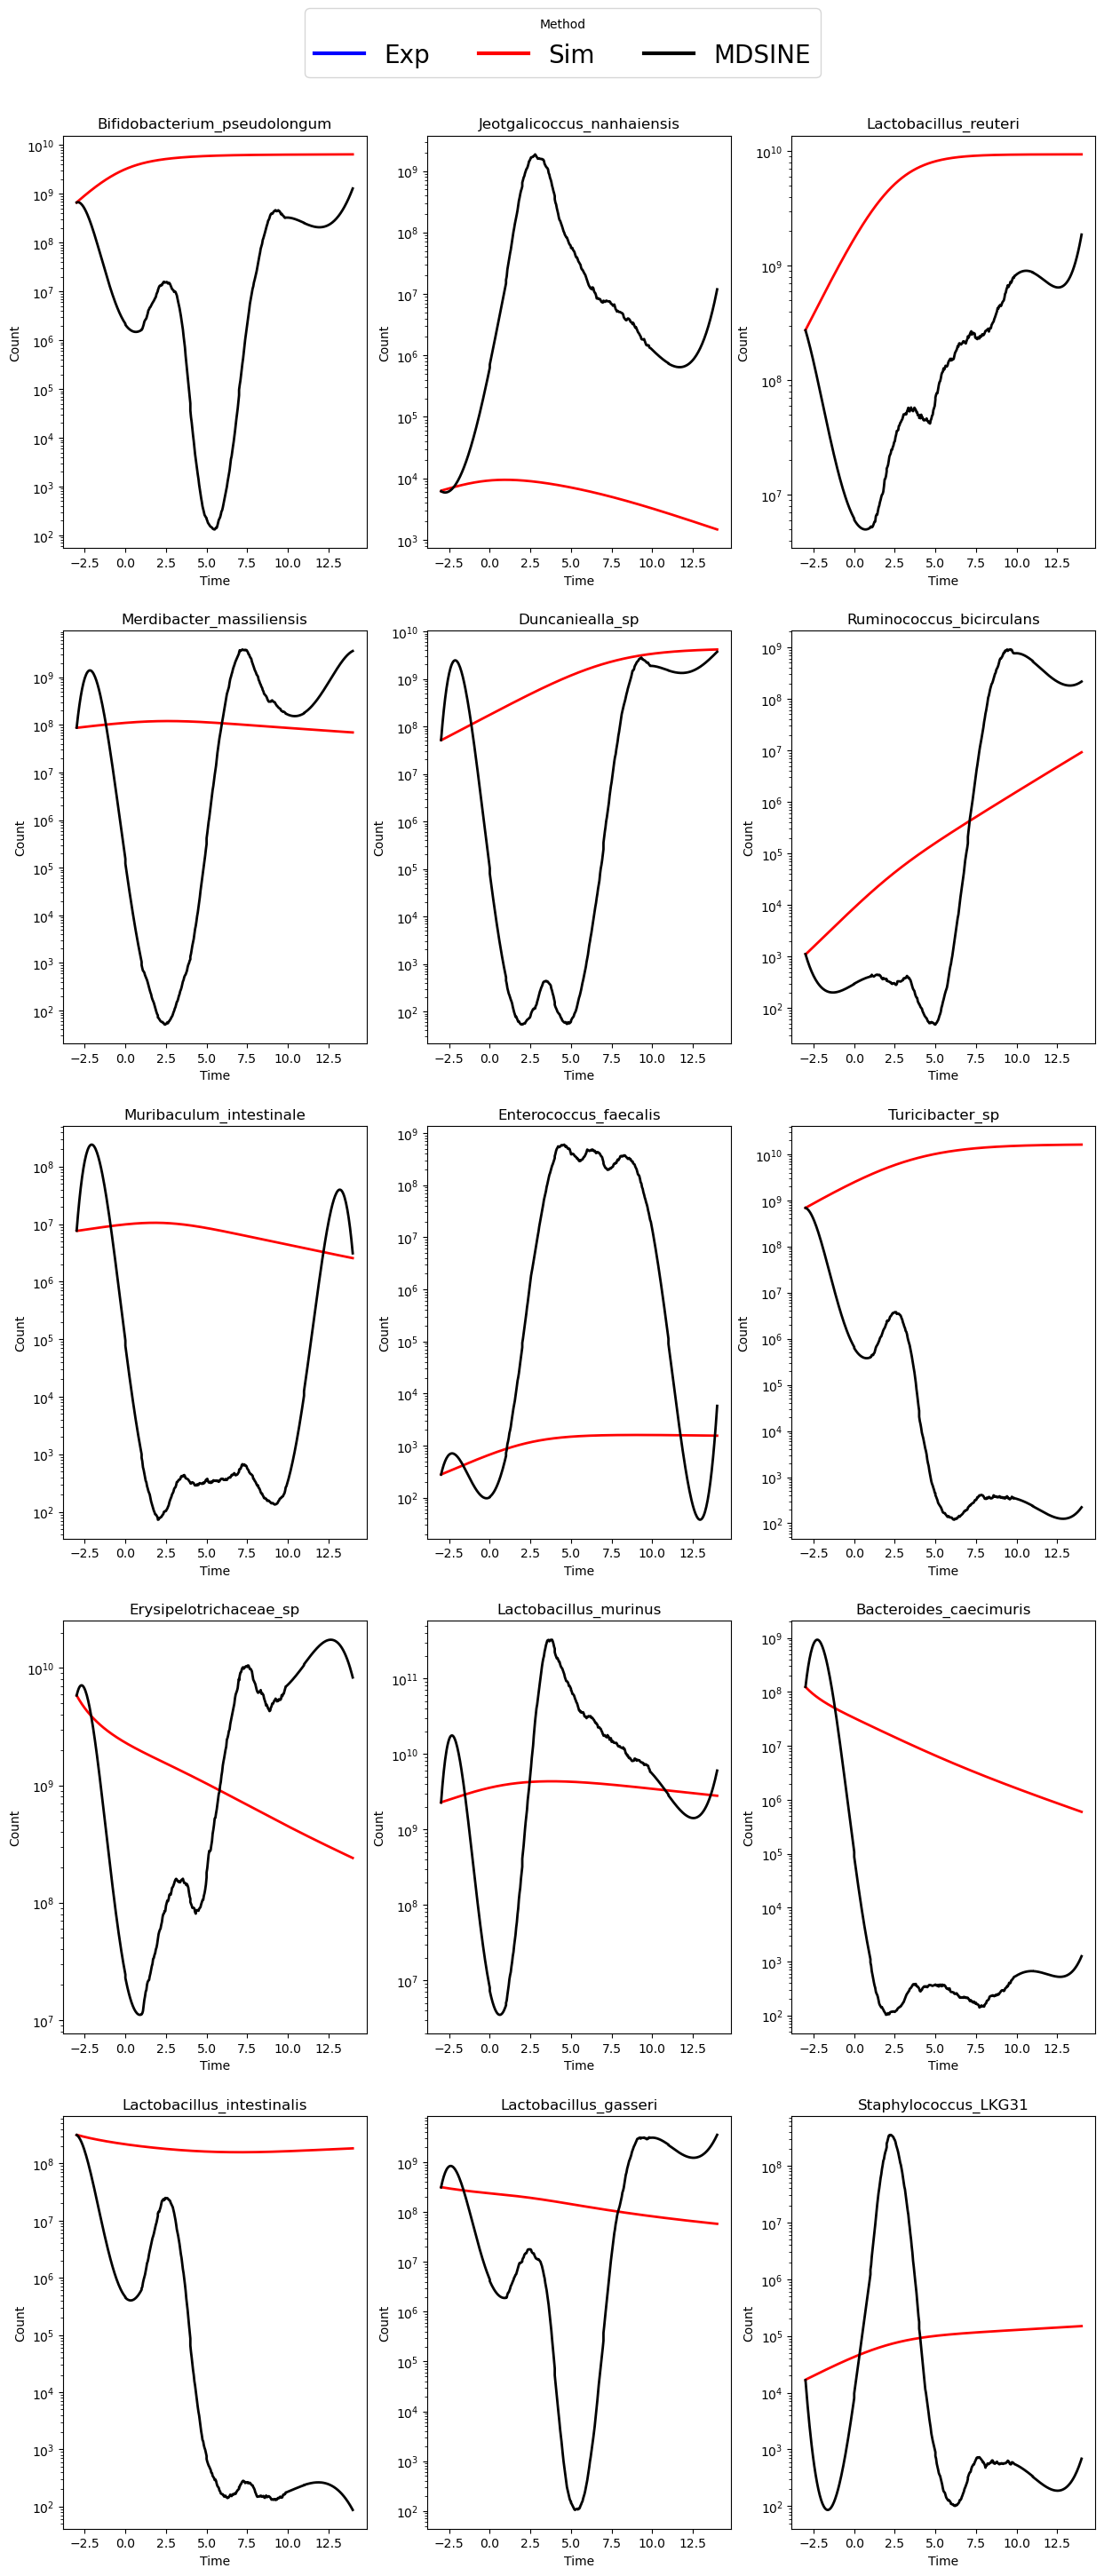

In [281]:
num_plots = 15
cols = 3  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 7), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, species in enumerate(asv_to_agora_dict.keys()):
    print(species)
    temp_sim = abun_test_df_melt[abun_test_df_melt['species'] == species]
    #temp_exp = testing_melt_abs_abun_plotting[testing_melt_abs_abun_plotting['species'] == species]
    temp_mdsine = MDSINE_output[MDSINE_output['species'] == species]
        # Scatter plot on the respective subplot
    
    #sns.lineplot(ax = axes[i], x = temp_exp['time'], y = temp_exp['count'], c = 'blue', lw = 2)
    sns.lineplot(ax=axes[i], x=temp_sim['time'], y=temp_sim['count'], c = 'red', lw =2)
    sns.lineplot(ax=axes[i], x=temp_mdsine['time'], y=temp_mdsine['count'], c = 'black', lw =2)
    
    species = asv_to_agora_dict[species]
    axes[i].set_title(f"{species}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Count')
    axes[i].set_yscale('log')
    
    

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Create color legend (data sources)
color_legend_elements = [
    Line2D([0], [0], color='blue', lw=3, label='Exp'),
    Line2D([0], [0], color='red', lw=3, label='Sim'),
    Line2D([0], [0], color='black', lw=3, label='MDSINE')
]


# Add both legends below the plots
color_legend = fig.legend(handles=color_legend_elements, loc='upper center', 
                          bbox_to_anchor=(.5, .925), ncol=3, fontsize=20, title="Method")
#axs.legend(['Mean EB Abun', 'EB 95% CI', 'Mean PC Abun', 'PC 95% CI', 'EB Data', 'PC Data'])
#plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_individual_scatterplots_smoothed_predictions' + str(test_num) + '.pdf'
#plt.savefig(plot_file_name, bbox_inches="tight")

In [206]:
# You CAN'T reproduce latent traces exactly, but you CAN:
# 1. Verify forward simulations are in the ballpark
# 2. Check that they capture the general trends

import matplotlib.pyplot as plt

# Extract latent traces
latent_abundances = mcmc.graph['1953'].get_trace_from_disk(section='posterior')
mean_latent = np.mean(latent_abundances, axis=0)

# Forward simulate from posterior mean parameters
growth = np.mean(mcmc.graph[STRNAMES.GROWTH_VALUE].get_trace_from_disk(section='posterior'), axis=0)
interactions = np.mean(mcmc.graph[STRNAMES.INTERACTIONS_OBJ].get_trace_from_disk(section='posterior'), axis=0)
self_int = np.mean(mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE].get_trace_from_disk(section='posterior'), axis=0)

for i in range(len(growth)):
    interactions[i, i] = -np.abs(self_int[i])

# Get initial condition from latent trace
init_abun = mean_latent[:, 0].reshape(-1, 1)

# Forward simulate
dyn = md2.model.gLVDynamicsSingleClustering(
    growth=growth,
    interactions=interactions,
    perturbations=None,
    start_day=subject.times[0]
)

X_forward = md2.integrate(
    dynamics=dyn,
    initial_conditions=init_abun,
    dt=0.1,
    subsample=True,
    times=subject.times
)

# Compare - they will NOT match exactly, but should be similar
fig, axes = plt.subplots(5, 3, figsize=(15, 12))
axes = axes.flatten()

for i in range(min(len(growth), 15)):
    axes[i].plot(subject.times, mean_latent[i, :], 'o-', label='Latent (mean.tsv)', alpha=0.7)
    axes[i].plot(subject.times, X_forward['X'][i, :], 's-', label='Forward sim', alpha=0.7)
    axes[i].set_title(f'Taxon {i}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Abundance')
    if i == 0:
        axes[i].legend()

plt.tight_layout()
plt.savefig('latent_vs_forward.png', dpi=150)
plt.show()

# Quantify difference
print("Mean absolute difference:", np.mean(np.abs(mean_latent - X_forward['X'])))
print("Correlation per taxon:", [np.corrcoef(mean_latent[i], X_forward['X'][i])[0,1] 
                                  for i in range(len(growth))])

UndefinedError: `id` (<class 'mdsine2.base.subject.Subject'>), "<mdsine2.base.subject.Subject object at 0x305ee90d0>" not recognized in graph `merged_studies_fixed_cluster_hourly_resolution`